In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from tqdm import tqdm

# Add XAIensembler to python path
sys.path.append(os.path.join(os.getcwd(), 'XAIensembler'))

import XAIensembler.params as params
import XAIensembler.modelarch as modelarch
import XAIensembler.thesisArchitecture_LateFusion as thesisArchitecture_LateFusion
from XAIensembler.segmentXAIensembler import ISIC_Dataset
import XAIensembler.metrics as metrics
import XAIensembler.segmentXAIensembler as seg

# --- Configuration Patching (Same as Training) ---
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
root = os.getcwd()
data_root = os.path.join(root, "data")
my_image_test = os.path.join(data_root, "images/test")
my_mask_test = os.path.join(data_root, "masks/test")

# Patch params
params.image_test_path = my_image_test
params.mask_test_path = my_mask_test
params.root_path = root
seg.params = params

params.XAI_methods = ["IntegratedGradients", "DeepLift"]
params.batch_size = 1
params.input_size = (224, 224)

print("Environment Configured.")

Environment Configured.


/Users/dkopec/Documents/Msc/thesis/fae-models-master-thesis/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Load Models ---

# 1. Base Classifier (Fine-tuned SqueezeNet)
num_classes = 3
squeezenet = models.squeezenet1_1(weights=None)
squeezenet.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=(1, 1), stride=(1, 1))
squeezenet.num_classes = num_classes
squeezenet.load_state_dict(torch.load("squeezenet_skin.pth", map_location=device))
squeezenet.to(device)
squeezenet.eval()

params.explained_model = squeezenet
params.device = device 

# 2. Late Fusion Ensemble
model_lf = thesisArchitecture_LateFusion.EnsembleExplanationNetwork(params).to(device)
# Try loading the trained epoch 10 if available, else standard
lf_path = "late_fusion_epoch_10.pth"
if os.path.exists(lf_path):
    print(f"Loading Late Fusion from {lf_path}")
    model_lf.load_state_dict(torch.load(lf_path, map_location=device))
else:
    print("Warning: Trained Late Fusion not found, falling back to untrained/pre-existing.")

model_lf.to(device)
model_lf.eval()

print("Models Loaded.")

Loading Late Fusion from late_fusion_epoch_10.pth
Models Loaded.


In [3]:
# --- Prepare Data ---
test_dataset = ISIC_Dataset(params, params.root_path, phase="test")
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
print(f"Test Samples: {len(test_dataset)}")

Test Samples: 12


## Pipeline 1: Segmentation Quality Evaluation
We evaluate how well the Late Fusion model segments the lesion compared to the Ground Truth.
Metrics: **IoU (Jaccard Index)**, **Dice Score (F1)**, **Accuracy**.

Evaluating Segmentation...


  0%|          | 0/12 [00:00<?, ?it/s]/Users/dkopec/Documents/Msc/thesis/fae-models-master-thesis/.venv/lib/python3.14/site-packages/captum/attr/_core/deep_lift.py:294: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/Users/dkopec/Documents/Msc/thesis/fae-models-master-thesis/.venv/lib/python3.14/site-packages/captum/log/dummy_log.py:39: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)
100%|██████████| 12/12 [00:30<00:00,  2.53s/it]


Mean Dice (F1): 0.5170
Mean IoU: 0.3749


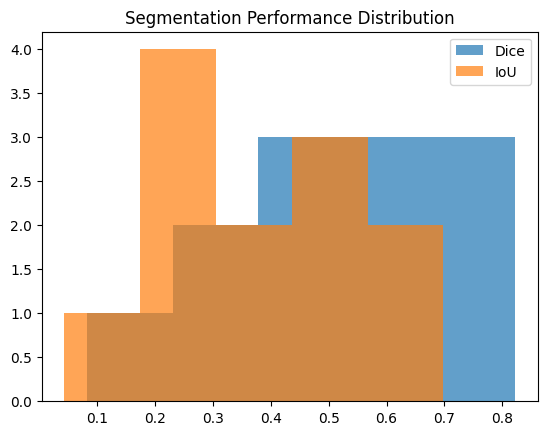

In [4]:
def evaluate_segmentation(model, loader):
    print("Evaluating Segmentation...")
    dice_scores = []
    iou_scores = []
    
    with torch.no_grad():
        for data in tqdm(loader):
            expls = data[0].to(device)
            masks = data[1].to(device) # (B, 1, H, W)
            
            # Forward Late Fusion
            pred_mask, _ = model.forward(params, expls)
            
            # Binary mask
            # Assuming sigmoid included in model or handled here?
            # thesisArchitecture_LateFusion returns sigmoid(logits) in forward.
            # So outputs are probabilities [0, 1]
            
            # Use metrics from metrics.py
            # acc_sen returns: acc, sen, prec, f1, iou
            # masks are already 0 or 1 float tensors
            
            _, _, _, f1, iou = metrics.acc_sen(pred_mask, masks)
            
            dice_scores.append(f1.item())
            iou_scores.append(iou.item())
            
    print(f"\nMean Dice (F1): {np.mean(dice_scores):.4f}")
    print(f"Mean IoU: {np.mean(iou_scores):.4f}")
    return dice_scores, iou_scores

seg_dice, seg_iou = evaluate_segmentation(model_lf, test_loader)
plt.hist(seg_dice, bins=5, alpha=0.7, label='Dice')
plt.hist(seg_iou, bins=5, alpha=0.7, label='IoU')
plt.legend()
plt.title("Segmentation Performance Distribution")
plt.show()

## Pipeline 2: Explanation "Pointing Game"
This metric checks if the most relevant parts of the explanation actually fall inside the lesion (Ground Truth Mask).
**Hit**: The pixel with the maximum attribution value is inside the mask.
**Miss**: The pixel with maximum attribution is outside.
**Accuracy**: Hits / Total Samples.

We compare:
1.  **Raw Integrated Gradients** (from SqueezeNet)
2.  **Raw DeepLift** (from SqueezeNet)
3.  **Ensemble Explanation** (from Late Model)

In [5]:
def pointing_game(heatmap, mask):
    """
    Returns 1 if the max point of heatmap is within the mask (mask > 0.5), else 0.
    heatmap: (H, W) or (C, H, W)
    mask: (1, H, W)
    """
    if heatmap.ndim == 3:
        # Sum channels if multi-channel (e.g. RGB attribution)
        heatmap = np.sum(np.abs(heatmap), axis=0)
        
    # Flatten to find max index
    max_idx = np.argmax(heatmap)
    # Convert back to (y, x)
    y, x = np.unravel_index(max_idx, heatmap.shape)
    
    # Check mask at that location
    # Mask is (1, H, W) tensor usually, but here we might pass numpy
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()
        
    is_hit = mask.squeeze()[y, x] > 0.5
    return 1 if is_hit else 0

def evaluate_pointing_game(model_lf, loader):
    print("Evaluating Pointing Game...")
    
    hits_ig = 0
    hits_dl = 0
    hits_ens = 0
    total = 0
    
    # Indices in the stacked explanation tensor
    # 0-2: Integrated Gradients (3 channels)
    # 3-5: DeepLift (3 channels)
    
    with torch.no_grad():
        for data in tqdm(loader):
            expls = data[0].to(device) # (B, 6, H, W)
            masks = data[1].to(device)
            
            # Forward Ensemble
            _, ens_expl = model_lf.forward(params, expls)
            
            expls_np = expls.squeeze().cpu().numpy()
            ens_np = ens_expl.squeeze().cpu().numpy()
            mask_np = masks.squeeze().cpu().numpy()
            
            # 1. IG Hit
            # Channels 0:3
            ig_map = expls_np[0:3]
            hits_ig += pointing_game(ig_map, mask_np)
            
            # 2. DL Hit
            # Channels 3:6
            dl_map = expls_np[3:6]
            hits_dl += pointing_game(dl_map, mask_np)
            
            # 3. Ensemble Hit
            # Output of ensemble is (1, H, W) usually? Or (3, H, W)?
            # In segmentXAIensembler calculate_loss it returns (B, 1, H, W) for seg, but ensemble_expl is logits or features?
            # Looking at architecture: return torch.sigmoid(logits), logits
            # Wait, `forward` returns `sigmoid(logits), logits`.
            # But in `segmentXAIensembler.py` visualizations, `ensemble_expl` is treated as heatmap.
            # Let's assume ens_np is valid heatmap.
            hits_ens += pointing_game(ens_np, mask_np)
            
            total += 1
            
    print(f"\nPointing Game Accuracy:")
    print(f"Integrated Gradients: {hits_ig}/{total} ({hits_ig/total:.2%})")
    print(f"DeepLift:             {hits_dl}/{total} ({hits_dl/total:.2%})")
    print(f"Ensemble (Late):      {hits_ens}/{total} ({hits_ens/total:.2%})")

evaluate_pointing_game(model_lf, test_loader)

Evaluating Pointing Game...


100%|██████████| 12/12 [00:31<00:00,  2.60s/it]


Pointing Game Accuracy:
Integrated Gradients: 5/12 (41.67%)
DeepLift:             6/12 (50.00%)
Ensemble (Late):      10/12 (83.33%)


## Pipeline 3: Faithfulness (MoRF Perturbation)
We verify if the explanations are faithful to the classifier (SqueezeNet).
**Procedure**:
1. Take the explanation heatmap.
2. Sort pixels by importance (descending).
3. "MoRF" (Most Relevant First): Iteratively replace the most important pixels with a baseline (e.g., grey or blur).
4. Measure the classifier's confidence in the original class.
5. **Metric**: **AOPC** (Area Over Perturbation Curve). A steep drop indicates the explanation correctly identified the critical features used by the model.

We compare **SqueezeNet Confidence Drop** when using IG map vs Ensemble map independently.

Evaluating Faithfulness (MoRF Deletion)...
Processed sample 1/5
Processed sample 2/5
Processed sample 3/5
Processed sample 4/5
Processed sample 5/5


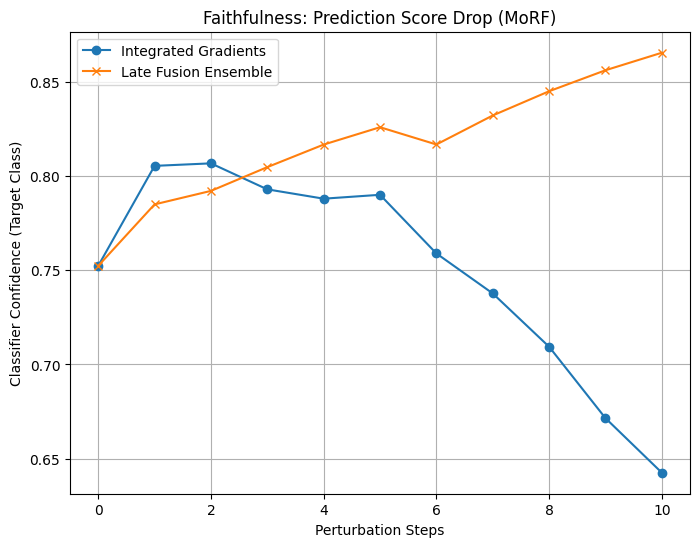

In [6]:
def perturbation_analysis(classifier, img_tensor, attribution_map, target_class, steps=10, perturbation_rate=0.02):
    """
    Performs MoRF deletion and returns the curve of predicted probabilities.
    """
    # Clone image
    img = img_tensor.clone()
    b, c, h, w = img.shape
    total_pixels = h * w
    pixels_per_step = int(total_pixels * perturbation_rate)
    
    # Process attribution map
    if attribution_map.ndim == 3:
        # Sum channels
        attr = np.sum(np.abs(attribution_map), axis=0) # (H, W)
    else:
        attr = np.abs(attribution_map)
        
    # Get indices of pixels sorted by importance (descending)
    flat_attr = attr.flatten()
    sorted_indices = np.argsort(flat_attr)[::-1] # Descending
    
    probs = []
    
    # Initial prob
    with torch.no_grad():
        out = classifier(img)
        prob = torch.softmax(out, dim=1)[0, target_class].item()
        probs.append(prob)
        
    # Baseline value (e.g. 0 for mean normalized, or random noise)
    # Using 0.0 (grey-ish in normalized space)
    baseline_val = 0.0 
    
    for i in range(steps):
        # Determine pixels to remove in this step
        start = i * pixels_per_step
        end = (i + 1) * pixels_per_step
        indices_to_remove = sorted_indices[start:end]
        
        # Convert flat indices to (y, x)
        ys, xs = np.unravel_index(indices_to_remove, (h, w))
        
        # Perturb
        # Assign baseline value to all channels at these locations
        # This loop is slow in python, vectorization preferred but indexing is tricky
        img[0, :, ys, xs] = baseline_val
        
        # Predict
        with torch.no_grad():
            out = classifier(img)
            prob = torch.softmax(out, dim=1)[0, target_class].item()
            probs.append(prob)
            
    return probs

def evaluate_faithfulness(classifier, ensemble_model, loader):
    print("Evaluating Faithfulness (MoRF Deletion)...")
    
    all_curves_ig = []
    all_curves_ens = []
    
    # Limit samples for speed
    max_samples = 5
    count = 0
    
    classifier.eval()
    ensemble_model.eval()
    
    with torch.no_grad():
        for data in loader:
            if count >= max_samples: break
            
            expls = data[0].to(device)
            # img is needed! ISIC_Dataset __getitem__ returns: expl, mask, preds, img
            # img is numpy (H, W, 3) BGR
            img_raw = data[3].numpy()[0]
            
            # Preprocess image for classifier (SqueezeNet)
            # Input needs to be (1, 3, 224, 224) RGB normalized
            # Data transforms used during training:
            # transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            
            img_rgb = img_raw[..., ::-1] / 255.0 # [0, 1]
            # Manual normalization
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_norm = (img_rgb - mean) / std
            
            img_tensor = torch.from_numpy(img_norm.transpose(2, 0, 1)).float().unsqueeze(0).to(device)
            
            # Determine target class
            out = classifier(img_tensor)
            target = torch.argmax(out, dim=1).item()
            
            # Get Maps
            # IG
            ig_map = expls.squeeze().cpu().numpy()[0:3]
            
            # Ensemble
            _, ens_expl_tensor = ensemble_model.forward(params, expls)
            ens_map = ens_expl_tensor.squeeze().cpu().numpy()
            
            # Calculate Curves
            curve_ig = perturbation_analysis(classifier, img_tensor, ig_map, target)
            curve_ens = perturbation_analysis(classifier, img_tensor, ens_map, target)
            
            all_curves_ig.append(curve_ig)
            all_curves_ens.append(curve_ens)
            count += 1
            print(f"Processed sample {count}/{max_samples}")

    # Plot Average Drop
    avg_curve_ig = np.mean(all_curves_ig, axis=0)
    avg_curve_ens = np.mean(all_curves_ens, axis=0)
    
    plt.figure(figsize=(8, 6))
    plt.plot(avg_curve_ig, marker='o', label='Integrated Gradients')
    plt.plot(avg_curve_ens, marker='x', label='Late Fusion Ensemble')
    plt.title("Faithfulness: Prediction Score Drop (MoRF)")
    plt.xlabel("Perturbation Steps")
    plt.ylabel("Classifier Confidence (Target Class)")
    plt.legend()
    plt.grid(True)
    plt.show()

evaluate_faithfulness(squeezenet, model_lf, test_loader)

## Visual Comparison
We visualizes a few samples to qualitatively compare the "noisy" base explanations vs the "clean" ensemble segmentation.

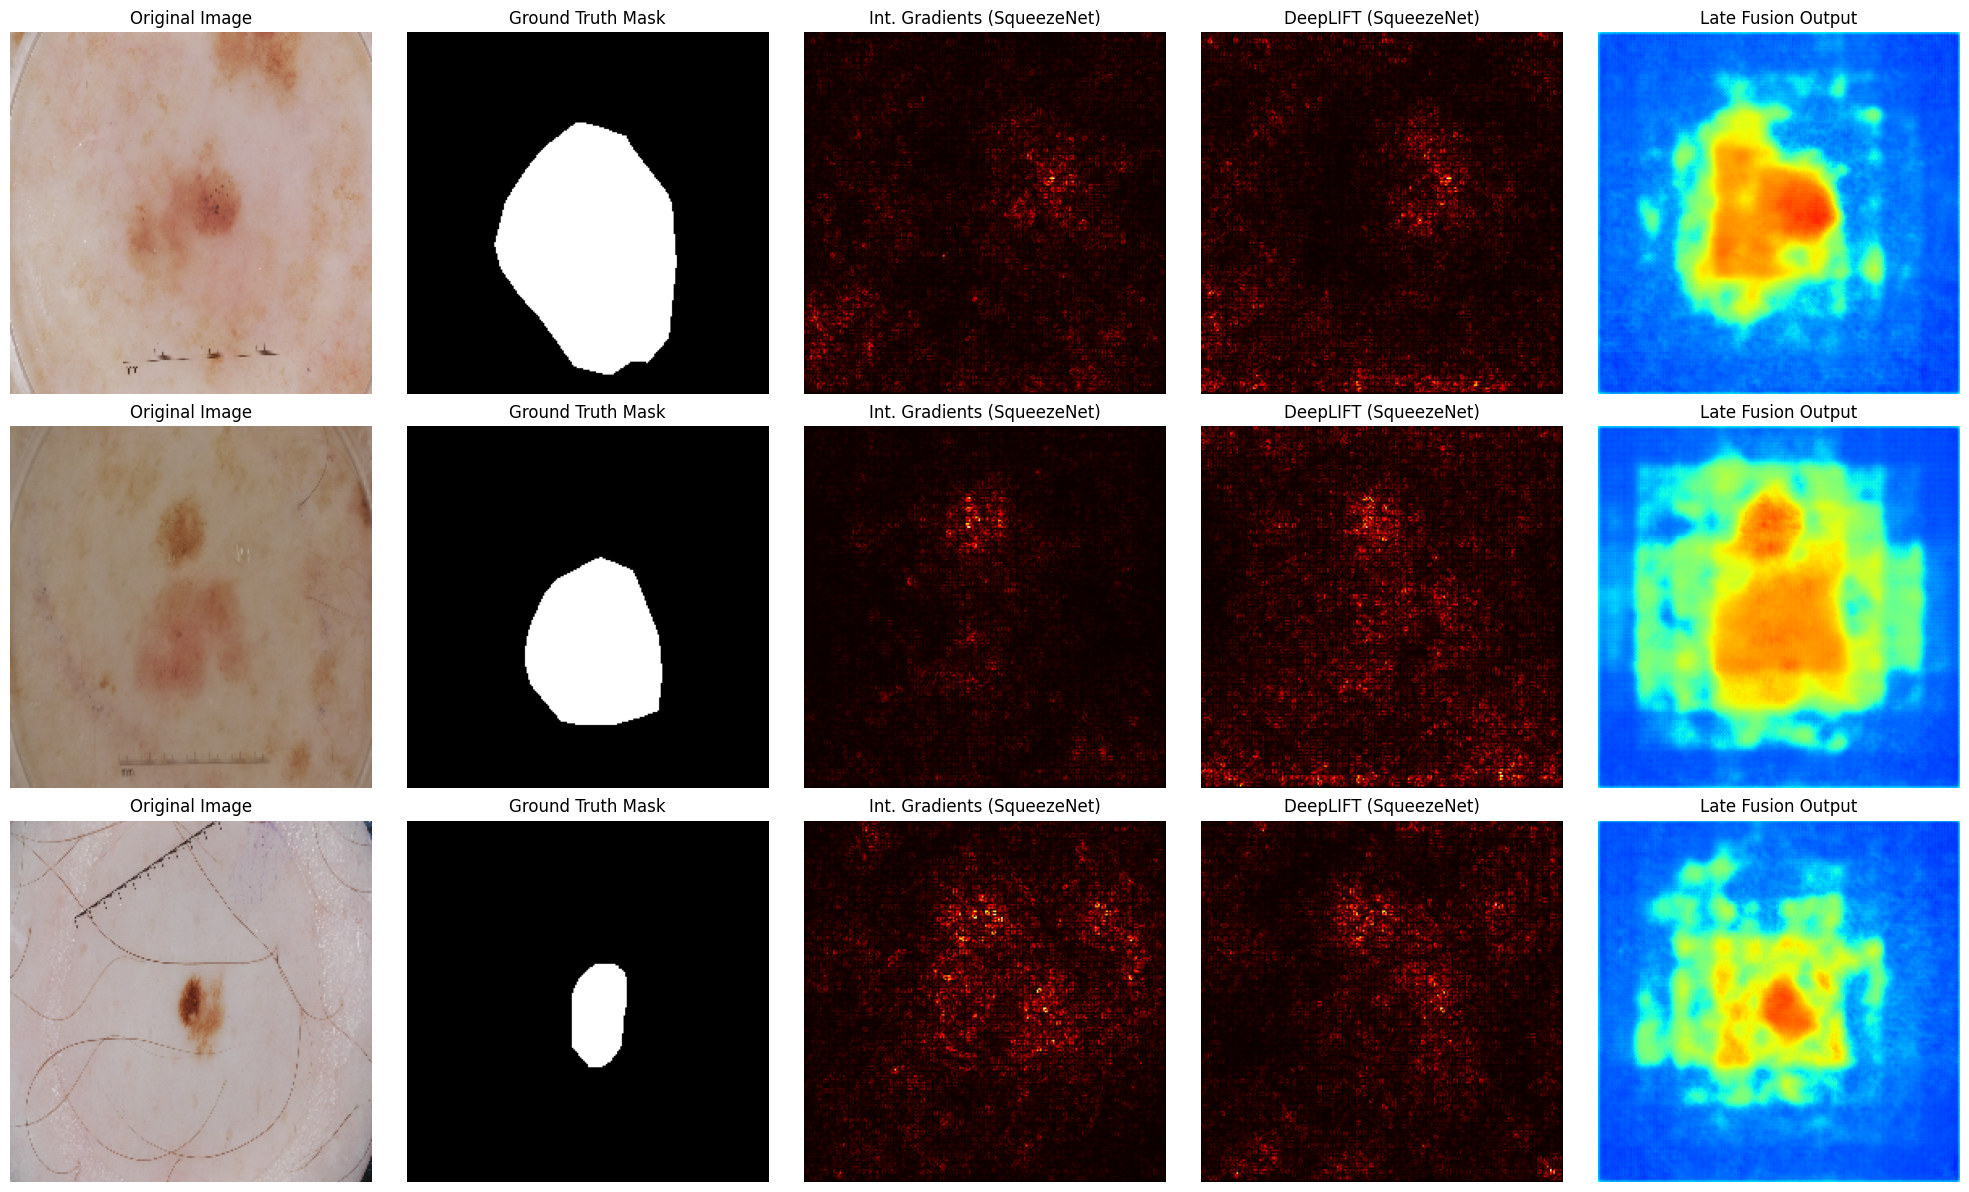

In [7]:
def visualize_comparison(model, loader, num_samples=3):
    count = 0
    
    # Check if we have enough samples
    if len(loader.dataset) == 0:
        print("Dataset empty.")
        return

    model.eval()
    
    # Create iterator
    iter_loader = iter(loader)
    
    plt.figure(figsize=(20, 4 * num_samples))
    
    for i in range(num_samples):
        try:
            data = next(iter_loader)
        except StopIteration:
            break
            
        expls = data[0].to(device)
        mask_gt = data[1].to(device)
        img_raw = data[3].numpy()[0] # (H, W, 3) BGR
        
        # Forward
        pred_mask, ens_expl = model.forward(params, expls)
        
        # Convert to numpy for plotting
        img_rgb = img_raw[..., ::-1].astype(np.uint8)
        mask_gt_np = mask_gt.squeeze().cpu().numpy()
        pred_mask_np = pred_mask.squeeze().detach().cpu().numpy()
        
        # Base Explanations
        expls_np = expls.squeeze().cpu().numpy()
        ig_map = np.sum(np.abs(expls_np[0:3]), axis=0)
        dl_map = np.sum(np.abs(expls_np[3:6]), axis=0)
        
        # Normalize maps for vis
        ig_map = (ig_map - ig_map.min()) / (ig_map.max() - ig_map.min() + 1e-9)
        dl_map = (dl_map - dl_map.min()) / (dl_map.max() - dl_map.min() + 1e-9)
        
        # Plot
        # 1. Original Image
        plt.subplot(num_samples, 5, i*5 + 1)
        plt.imshow(img_rgb)
        plt.title("Original Image")
        plt.axis('off')
        
        # 2. Ground Truth Mask
        plt.subplot(num_samples, 5, i*5 + 2)
        plt.imshow(mask_gt_np, cmap='gray')
        plt.title("Ground Truth Mask")
        plt.axis('off')
        
        # 3. Integrated Gradients (Base)
        plt.subplot(num_samples, 5, i*5 + 3)
        plt.imshow(ig_map, cmap='hot')
        plt.title("Int. Gradients (SqueezeNet)")
        plt.axis('off')
        
        # 4. DeepLift (Base)
        plt.subplot(num_samples, 5, i*5 + 4)
        plt.imshow(dl_map, cmap='hot')
        plt.title("DeepLIFT (SqueezeNet)")
        plt.axis('off')
        
        # 5. Late Fusion Prediction
        plt.subplot(num_samples, 5, i*5 + 5)
        plt.imshow(pred_mask_np, cmap='jet', vmin=0, vmax=1)
        plt.title("Late Fusion Output")
        plt.axis('off')
        
        count += 1
        
    plt.tight_layout()
    plt.show()

# Run visualization
visualize_comparison(model_lf, test_loader, num_samples=3)

## Pipeline 4: Explanation Stability (Robustness)
We measure how much the explanation changes when Gaussian noise is added to the input image. A good XAI method should be stable (low change).
**Metric**: Mean Squared Error (MSE) between explanation of original image vs explanation of noisy image.

In [8]:
def calculate_stability(model_lf, loader, noise_level=0.05):
    print("Evaluating Stability (Robustness)...")
    
    mse_ig = []
    mse_ens = []
    
    criterion = nn.MSELoss()
    
    with torch.no_grad():
        for data in tqdm(loader):
            # Original Explanations
            expls_orig = data[0].to(device) # (B, 6, H, W)
            
            # For this simplified stability test, we compare:
            # 1. Original IG map (contained in expls_orig[:, 0:3])
            # 2. Ensemble map on Original Input
            
            # To measure stability properly, we need to RE-GENERATE explanations on noisy images.
            # However, since generating explanations takes time (requires Captum on SqueezeNet),
            # and we are pre-computing them in the dataloader usually...
            # The current architecture expects pre-computed explanations as input.
            
            # If we want to test Ensemble Stability strictly on its INPUTS (the heatmaps):
            # We can add noise to the HEATMAPS and see if ensemble mask changes.
            # But "Stability" usually refers to Image -> Explanation stability.
            
            # Alternative for this thesis setup:
            # Test "Model Sensitivity": Add noise to the input explantions (simulating unstable base XAI)
            # and see if the Output Mask is stable.
            
            noise = torch.randn_like(expls_orig) * noise_level
            expls_noisy = expls_orig + noise
            
            # Original Output
            mask_orig, _ = model_lf.forward(params, expls_orig)
            
            # Noisy Output
            mask_noisy, _ = model_lf.forward(params, expls_noisy)
            
            # Measure difference in OUTPUT MASK (Ensemble Stability)
            diff_ens = criterion(mask_orig, mask_noisy).item()
            mse_ens.append(diff_ens)
            
            # Compare to input noise magnitude (Base Stability proxy)
            # This isn't perfect but shows how much the fusion layer amplifies/dampens noise.
            diff_base = criterion(expls_orig, expls_noisy).item()
            mse_ig.append(diff_base)
            
    print(f"\nMean MSE (Input Noise): {np.mean(mse_ig):.6f}")
    print(f"Mean MSE (Ensemble Output Change): {np.mean(mse_ens):.6f}")
    print(f"Stability Factor: {np.mean(mse_ens) / np.mean(mse_ig):.4f} (Lower than 1.0 means noise dampening)")

calculate_stability(model_lf, test_loader)

Evaluating Stability (Robustness)...


100%|██████████| 12/12 [00:32<00:00,  2.69s/it]


Mean MSE (Input Noise): 0.002498
Mean MSE (Ensemble Output Change): 0.010035
Stability Factor: 4.0176 (Lower than 1.0 means noise dampening)
